In [1]:
# ── Environment setup ──
import json
import os
import faiss
import math
import random
import string
import time
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, normalize
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "v1").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "v1").exists():
    PROJECT_ROOT = Path.home() / "Desktop/projects/game_recommender_system"

V1_DIR = PROJECT_ROOT / "v1"
RAW_DIR = V1_DIR / "data/raw"
PROCESSED_DIR = V1_DIR / "data/processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Reproducibility
RANDOM_SEED = 42
# Data sampling: reservoir-sample 3K users with ≥20 reviews to keep memory tractable
TARGET_SAMPLED_ACTIVE_USERS = 3_000
MIN_RAW_REVIEWS = 20
USER_CHUNK_SIZE = 500_000
INTERACTION_CHUNK_SIZE = 250_000

# Temporal split ratios (per-user chronological, not random)
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
MIN_TRAIN_ITEM_POSITIVES = 5
MIN_TRAIN_USER_EVENTS = 5
MIN_TRAIN_USER_POSITIVES = 2

# Model and training
MAX_HISTORY_LENGTH = 50
BATCH_SIZE = 512
EMBEDDING_DIM = 128

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


# ── Best configuration (from ablation study) ──
# no_user_id: removes per-user collaborative embedding — forces history-only
# generalization. Ablation study showed +19.8% test recall over the full model.
# Keeps multi-head self-attention over history and popularity blend at inference.
ABLATION = "no_user_id"
#
# Ablation variants (uncomment to re-run experiments):
# ABLATION = "full"           # original v1 with all components
# ABLATION = "no_popularity"  # HYBRID_ALPHA = 0
# ABLATION = "mean_pool"      # replace attention with mean pooling


In [2]:
# ── Cleanup helper (uncomment before re-running with different ABLATION) ──
# Removes processed data and model checkpoints so each ablation starts fresh.
# import shutil
# for d in [PROCESSED_DIR, V1_DIR / "models"]:
#     if d.exists():
#         shutil.rmtree(d)
#         print(f"Cleaned {d}")
# PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
print(f"Running ABLATION = '{ABLATION}'")




Running ABLATION = 'no_user_id'


In [3]:
# ── Raw data loading ──
# Games catalog (50K+ titles) and metadata (tags + descriptions per game).

games = pd.read_csv(RAW_DIR / "games.csv")
games_metadata = pd.read_json(RAW_DIR / "games_metadata.json", lines=True)



In [4]:
# ── User sampling ──
# Reservoir sampling over the 14M-user table selects a uniform random subset
# of 3,000 active users (≥20 reviews) in a single streaming pass — O(n) time,
# O(k) memory, no need to load the full user table into RAM.

rng = random.Random(RANDOM_SEED)
reservoir = []
eligible_users_seen = 0

for user_chunk in pd.read_csv(
    RAW_DIR / "users.csv",
    usecols=["user_id", "reviews"],
    chunksize=USER_CHUNK_SIZE,
):
    eligible_user_ids = user_chunk.loc[
        user_chunk["reviews"] >= MIN_RAW_REVIEWS,
        "user_id",
    ]
    for user_id in eligible_user_ids:
        eligible_users_seen += 1
        if len(reservoir) < TARGET_SAMPLED_ACTIVE_USERS:
            reservoir.append(int(user_id))
        else:
            replacement_idx = rng.randint(0, eligible_users_seen - 1)
            if replacement_idx < TARGET_SAMPLED_ACTIVE_USERS:
                reservoir[replacement_idx] = int(user_id)

sampled_user_ids = set(reservoir)
chunks = []
for interaction_chunk in pd.read_csv(
    RAW_DIR / "recommendations.csv",
    chunksize=INTERACTION_CHUNK_SIZE,
):
    sampled_chunk = interaction_chunk[
        interaction_chunk["user_id"].isin(sampled_user_ids)
    ]
    if not sampled_chunk.empty:
        chunks.append(sampled_chunk)

interactions = pd.concat(chunks, ignore_index=True)
del chunks, reservoir, sampled_user_ids

print(
    f"Loaded {len(interactions):,} interactions for "
    f"{interactions['user_id'].nunique():,} sampled active users."
)



Loaded 117,503 interactions for 3,000 sampled active users.


In [5]:
# ── Interaction cleanup ──
# Deduplicate reviews, enforce consistent dtypes, and drop rows with missing
# keys. These transformations mirror v0 preprocessing; downstream feature
# scaling (log-transforms, clipping, MinMax) happens after the temporal split
# to avoid train/test leakage.

interactions.drop_duplicates(subset=["review_id"], keep="first", inplace=True)
interactions.drop(columns=["review_id"], inplace=True)
interactions["date"] = pd.to_datetime(interactions["date"], errors="coerce")
interactions.dropna(subset=["user_id", "app_id", "date"], inplace=True)
interactions["user_id"] = interactions["user_id"].astype("int64")
interactions["app_id"] = interactions["app_id"].astype("int64")
interactions["is_recommended"] = interactions["is_recommended"].astype("int8")



In [6]:
# ── Engagement log-transforms ──
# Hours, helpful votes, and funny votes are heavy-tailed — log1p compresses
# the range while preserving ordinality. Clipping at 0 guards against any
# negative data artifacts.

ENGAGEMENT_COLUMNS = ["hours", "helpful", "funny"]
ENGAGEMENT_LOG_COLUMNS = [f"{column}_log" for column in ENGAGEMENT_COLUMNS]

for raw_column, log_column in zip(ENGAGEMENT_COLUMNS, ENGAGEMENT_LOG_COLUMNS):
    interactions[log_column] = np.log1p(interactions[raw_column].clip(lower=0))

# Raw engagement columns replaced by log-transformed versions above; drop originals.
interactions.drop(columns=ENGAGEMENT_COLUMNS, inplace=True)



In [7]:
# ── Chronological ordering + dataset summary ──
# Sort by (user, date) so temporal splits are contiguous slices, not random
# shuffles. Engagement clipping/scaling is deferred until after the split.

interactions.sort_values(["user_id", "date"], inplace=True)
interactions.reset_index(drop=True, inplace=True)

pd.Series({
    "sampled_users": interactions["user_id"].nunique(),
    "sampled_items": interactions["app_id"].nunique(),
    "sampled_interactions": len(interactions),
    "positive_rate": interactions["is_recommended"].mean(),
})




sampled_users             3000.000000
sampled_items            15068.000000
sampled_interactions    117503.000000
positive_rate                0.827894
dtype: float64

In [8]:
# ── Positive label ──
# is_recommended (boolean) → is_positive (int8). Positive interactions
# define the InfoNCE training targets and the held-out evaluation ground truth.

interactions["is_positive"] = interactions["is_recommended"].astype("int8")
# is_positive replaces is_recommended for all downstream use; drop the original.
interactions.drop(columns=["is_recommended"], inplace=True)



In [9]:
# ── Metadata cleaning ──
# Deduplicate games, fill missing text fields, and compute binary flags
# indicating which items have descriptions and/or tags. Games without ANY
# text metadata are still kept here — they serve as cold-start candidates.

games.drop_duplicates(subset=["app_id"], keep="first", inplace=True)
games_metadata.drop_duplicates(subset=["app_id"], keep="first", inplace=True)

games_metadata["description"] = games_metadata["description"].fillna("").astype(str)
games_metadata["tags"] = games_metadata["tags"].apply(
    lambda tags: tags if isinstance(tags, list) else []
)
games_metadata["has_description"] = (
    games_metadata["description"].str.strip() != ""
).astype("int8")
games_metadata["has_tags"] = (
    games_metadata["tags"].str.len() > 0
).astype("int8")
games_metadata["has_text_metadata"] = (
    (games_metadata["has_description"] == 1)
    | (games_metadata["has_tags"] == 1)
).astype("int8")



In [10]:
# ── Catalog intersection ──
# Keep only games present in BOTH the games table and metadata table.
# The full pre-intersection catalog is saved as fallback_games for cold-start
# recommendations (items without enough collaborative signal).

valid_catalog_app_ids = set(games_metadata["app_id"]) & set(games["app_id"])
games = games[games["app_id"].isin(valid_catalog_app_ids)].copy()
games_metadata = games_metadata[
    games_metadata["app_id"].isin(valid_catalog_app_ids)
].copy()
interactions = interactions[
    interactions["app_id"].isin(valid_catalog_app_ids)
].copy()

fallback_games = games.copy()



In [11]:
# ── Filter to interacted catalog ──
# Drop games that no sampled user ever touched — they carry no collaborative
# signal and inflate the candidate space without benefit.

interacted_app_ids = set(interactions["app_id"])
games = games[games["app_id"].isin(interacted_app_ids)].copy()
games_metadata = games_metadata[
    games_metadata["app_id"].isin(interacted_app_ids)
].copy()

games.reset_index(drop=True, inplace=True)
games_metadata.reset_index(drop=True, inplace=True)

# Sanity check: catalog size after filtering.
interactions["app_id"].nunique(), games.shape, games_metadata.shape



(15068, (15068, 13), (15068, 6))

In [12]:
# ── Catalog integrity checks ──
# Verify unique app_ids, non-null descriptions/list-typed tags, and print
# metadata coverage statistics before proceeding to feature engineering.

assert games_metadata["description"].notna().all()
assert games_metadata["tags"].apply(lambda tags: isinstance(tags, list)).all()
print(
    "Metadata availability:",
    games_metadata[
        ["has_description", "has_tags", "has_text_metadata"]
    ].mean().round(4).to_dict(),
)

assert games["app_id"].is_unique
assert games_metadata["app_id"].is_unique
print(f"Static catalog ready: {len(games):,} games.")



Metadata availability: {'has_description': 0.962, 'has_tags': 0.9624, 'has_text_metadata': 0.9624}
Static catalog ready: 15,068 games.


In [13]:
# ── Game feature engineering ──
# Drop unused price columns, one-hot encode rating categories and booleans,
# log1p-transform review counts and price to compress skew. Re-filter
# metadata and interactions to the surviving catalog.

games.drop(columns=["price_original", "discount"], inplace=True)

bool_cols = ["win", "mac", "linux", "steam_deck"]
games[bool_cols] = games[bool_cols].astype("int8")

games = pd.get_dummies(games, columns=["rating"], dtype="int8")

games["user_reviews"] = np.log1p(games["user_reviews"].clip(lower=0))
games["price_final"] = np.log1p(games["price_final"].clip(lower=0))

games["date_release"] = pd.to_datetime(games["date_release"], errors="coerce")
games.dropna(subset=["date_release"], inplace=True)

valid_catalog_app_ids = set(games["app_id"])
games_metadata = games_metadata[games_metadata["app_id"].isin(valid_catalog_app_ids)].copy()
interactions = interactions[interactions["app_id"].isin(valid_catalog_app_ids)].copy()

interactions["app_id"].nunique(), games.shape, games_metadata.shape



(15068, (15068, 19), (15068, 6))

In [14]:
# positive_ratio is stored as 0–100; rescale to [0, 1] so it is on the
# same footing as other numeric features before StandardScaling.

games["positive_ratio"] = games["positive_ratio"] / 100.0



In [15]:
# ── Description enrichment ──
# Append the game title to its description so the sentence-transformer
# embedding captures the name alongside gameplay text. Title column is then
# dropped from the games table to avoid duplication.

games_metadata = games_metadata.merge(
    games[["app_id", "title"]],
    on="app_id",
    how="inner",
    validate="one_to_one",
)

games.drop(columns=["title"], inplace=True)

games.sort_values("date_release", inplace=True)
games.reset_index(drop=True, inplace=True)

interactions.sort_values(["user_id", "date"], inplace=True)

# Full catalog exported after splitting (cell 30) — the warm (train-supported)
# subset is a strict subset of this.
print(
    f"Pre-split catalog: {len(games):,} games and "
    f"{len(interactions):,} aligned interactions."
)



Pre-split catalog: 15,068 games and 117,503 aligned interactions.


In [16]:
# ── Text cleaning for embeddings ──
# Tags carry broad genre/category signals; descriptions carry finer gameplay,
# story, and title text. Both are cleaned (HTML, URLs, punctuation stripped,
# whitespace collapsed) before being fed to sentence-transformers.

games_metadata["description_clean"] = (
    games_metadata["description"].fillna("").astype(str)
    + " "
    + games_metadata["title"].fillna("").astype(str)
).str.lower()
games_metadata.drop(columns=["title"], inplace=True)

games_metadata["tags_clean"] = games_metadata["tags"].apply(
    lambda tags: " ".join(str(tag) for tag in tags)
)


games_metadata["tags_clean"] = games_metadata["tags_clean"].apply(
    lambda text: text.translate(str.maketrans("", "", string.punctuation))
)
games_metadata["tags_clean"] = (
    games_metadata["tags_clean"].str.replace(r"\s+", " ", regex=True).str.strip()
)

games_metadata["description_clean"] = games_metadata["description_clean"].str.replace(
    r"<[^>]+>",
    " ",
    regex=True,
)
games_metadata["description_clean"] = games_metadata["description_clean"].str.replace(
    r"http\S+|www\.\S+",
    " ",
    regex=True,
)
games_metadata["description_clean"] = games_metadata["description_clean"].apply(
    lambda text: text.translate(str.maketrans("", "", string.punctuation))
)
games_metadata["description_clean"] = (
    games_metadata["description_clean"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)



In [17]:
# ── Tag embeddings ──
# MiniLM-L12 (384-dim) encodes cleaned tag strings. Items with no tags
# get a zero vector so they remain in the catalog without polluting the
# embedding space with noise from empty strings.

tag_model = SentenceTransformer("sentence-transformers/all-MiniLM-L12-v2")
tag_embeddings = tag_model.encode(
    games_metadata["tags_clean"].tolist(),
    show_progress_bar=True,
    normalize_embeddings=True,
)

tag_embeddings[games_metadata["has_tags"].to_numpy() == 0] = 0.0

tags_reduced = pd.DataFrame(
    tag_embeddings,
    columns=[f"tag_feature_{index}" for index in range(tag_embeddings.shape[1])],
)
tags_reduced.insert(0, "app_id", games_metadata["app_id"].values)
print(f"Tag embeddings shape: {tag_embeddings.shape}")



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/471 [00:00<?, ?it/s]

Tag embeddings shape: (15068, 384)


In [18]:
# ── Description embeddings ──
# MPNet (768-dim) encodes cleaned descriptions + title text. Zeroed out
# for items missing descriptions, same as tags above.

description_model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")
description_embeddings = description_model.encode(
    games_metadata["description_clean"].tolist(),
    show_progress_bar=True,
    normalize_embeddings=True,
)

description_embeddings[
    games_metadata["has_description"].to_numpy() == 0
] = 0.0
print(f"Description embeddings shape: {description_embeddings.shape}")



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/471 [00:00<?, ?it/s]

Description embeddings shape: (15068, 768)


In [19]:
# ── Embedding DataFrames ──
# Wrap raw numpy arrays in DataFrames keyed by app_id for clean merge
# operations downstream.

descriptions_reduced = pd.DataFrame(
    description_embeddings,
    columns=[
        f"description_feature_{index}"
        for index in range(description_embeddings.shape[1])
    ],
)
descriptions_reduced.insert(0, "app_id", games_metadata["app_id"].values)

tags_reduced.head()

descriptions_reduced.head()



,app_id,description_feature_0,description_feature_1,description_feature_2,description_feature_3,description_feature_4,description_feature_5,description_feature_6,description_feature_7,description_feature_8,...,description_feature_758,description_feature_759,description_feature_760,description_feature_761,description_feature_762,description_feature_763,description_feature_764,description_feature_765,description_feature_766,description_feature_767
0,13500,0.031731,0.003235,-0.017481,0.034875,-0.037862,0.010739,-0.089683,0.032234,-0.008871,...,-0.046950,0.015176,0.003270,0.040779,-0.013273,0.024003,0.036777,0.014520,-0.004160,-0.035008
1,113020,-0.001989,0.040883,0.002986,0.080191,-0.086518,-0.010974,0.006928,-0.010994,0.013169,...,-0.021919,-0.018059,0.040449,0.092892,-0.008293,-0.014874,-0.013607,-0.027279,0.015634,0.014560
2,226560,-0.026578,-0.031371,0.022785,-0.001398,0.003506,0.067450,-0.073055,-0.016160,0.024988,...,-0.003594,-0.015426,0.038444,-0.002914,0.020466,0.090645,-0.021190,0.019670,0.027688,0.016903
3,249050,0.003591,-0.012149,-0.002525,0.011271,-0.056125,-0.009646,-0.075692,0.016206,-0.017117,...,-0.060126,-0.013246,-0.052206,0.047137,-0.009472,-0.003618,-0.010775,0.039666,-0.011275,-0.030469
4,250180,-0.006297,-0.086185,0.015451,0.018034,-0.003725,0.043055,0.034496,-0.023664,-0.135105,...,-0.027215,0.064569,-0.029534,0.010647,0.030772,-0.052133,-0.017045,-0.000365,0.001903,0.038768


In [20]:
# ── Feature merge ──
# Inner-join games table with tag embeddings, description embeddings, and
# metadata availability flags into a single item-tower feature table.

metadata_availability = games_metadata[
    ["app_id", "has_description", "has_tags", "has_text_metadata"]
]
item_features_df = (
    games
    .merge(tags_reduced, on="app_id", how="inner", validate="one_to_one")
    .merge(
        descriptions_reduced,
        on="app_id",
        how="inner",
        validate="one_to_one",
    )
    .merge(
        metadata_availability,
        on="app_id",
        how="inner",
        validate="one_to_one",
    )
)



In [21]:
# ── Feature block extraction ──
# Partition columns into four blocks (numeric, binary, tag embeddings,
# description embeddings) so each block can be independently scaled and
# weighted before concatenation. Preserve app_ids and release dates.

numeric_cols = ["positive_ratio", "user_reviews", "price_final"]
binary_cols = [
    column
    for column in item_features_df.columns
    if column.startswith("rating_")
    or column in [
        "win",
        "mac",
        "linux",
        "steam_deck",
        "has_description",
        "has_tags",
        "has_text_metadata",
    ]
]
tag_cols = [
    column
    for column in item_features_df.columns
    if column.startswith("tag_feature_")
]
description_cols = [
    column
    for column in item_features_df.columns
    if column.startswith("description_feature_")
]

game_ids = item_features_df["app_id"].values
release_dates = item_features_df["date_release"].values

X_numeric = item_features_df[numeric_cols].to_numpy(dtype=np.float32)
X_binary = item_features_df[binary_cols].to_numpy(dtype=np.float32)
X_tags = item_features_df[tag_cols].to_numpy(dtype=np.float32)
X_descriptions = item_features_df[description_cols].to_numpy(dtype=np.float32)



In [22]:
# ── Block weighting and normalization ──
# Each feature block is independently L2-normalized before weighting so that
# cosine similarity reflects signal importance rather than raw magnitude.
# Block weights (15 % numeric, 15 % binary, 25 % tags, 45 % descriptions)
# were tuned on v0 validation; descriptions carry the most signal.
# Final concatenation is L2-normalized again for ANN-friendly inner products.

numeric_scaler = StandardScaler()
X_numeric = normalize(numeric_scaler.fit_transform(X_numeric))
X_binary = normalize(X_binary) if X_binary.shape[1] else X_binary

metadata_weight = 0.15
binary_weight = 0.15
tag_weight = 0.25
description_weight = 0.45

X_items = np.concatenate(
    [
        metadata_weight * X_numeric,
        binary_weight * X_binary,
        tag_weight * X_tags,
        description_weight * X_descriptions,
    ],
    axis=1,
)
X_items = normalize(X_items)

final_feature_cols = numeric_cols + binary_cols + tag_cols + description_cols
item_features_df = pd.DataFrame(X_items, columns=final_feature_cols)
item_features_df.insert(0, "app_id", game_ids)
item_features_df.insert(1, "date_release", release_dates)
item_features_df["date_release"] = pd.to_datetime(
    item_features_df["date_release"]
)

item_features_df.shape

item_features_df.head()



,app_id,date_release,positive_ratio,user_reviews,price_final,win,mac,linux,steam_deck,rating_Mixed,...,description_feature_758,description_feature_759,description_feature_760,description_feature_761,description_feature_762,description_feature_763,description_feature_764,description_feature_765,description_feature_766,description_feature_767
0,282010,1997-06-30,0.188473,0.013600,0.192025,0.109985,0.00000,0.00000,0.109985,0.0,...,-0.001518,0.020155,-0.033922,-0.011902,0.019308,0.060682,-0.031014,-0.017926,0.015146,-0.013887
1,232770,1997-11-14,0.053935,0.115687,-0.237252,0.095250,0.09525,0.09525,0.095250,0.0,...,0.023387,0.009864,-0.048884,-0.002791,0.027814,0.018277,0.016034,-0.014862,0.004232,0.040721
2,70,1998-11-08,0.106358,0.244404,0.039180,0.095250,0.09525,0.09525,0.095250,0.0,...,-0.017952,0.015462,-0.039243,0.026192,0.019361,-0.018780,0.009942,-0.017558,0.029301,0.023860
3,20,1999-04-01,0.081855,0.255041,-0.028884,0.095250,0.09525,0.09525,0.095250,0.0,...,0.000937,0.012278,-0.023075,0.034728,0.025348,0.032844,-0.012433,0.031146,0.025426,0.005613
4,50,1999-11-01,0.138169,0.230521,-0.018714,0.095250,0.09525,0.09525,0.095250,0.0,...,0.004798,0.005434,-0.023215,0.003715,0.027048,-0.065160,0.002623,0.017648,0.010990,0.000531


In [23]:
# ── Full catalog snapshots ──
# Snapshot the pre-filter catalog (including items without text metadata)
# before the train-supported stabilization step in cell 25. These full
# snapshots are used for cold-start fallback and offline coverage reporting.

full_games = games.copy()
full_games_meta = games_metadata.copy()
full_item_features = item_features_df.copy()

print(f"Full offline item-tower feature table: {full_item_features.shape}")



Full offline item-tower feature table: (15068, 1173)


In [24]:
# ── Per-user temporal split ──
# Each user's interaction history is sorted by date and sliced chronologically:
# earliest 70 % → train, next 15 % → validation, last 15 % → test.
# This prevents future information from leaking into the training set.

def temporal_split_by_user(frame, train_ratio=TRAIN_RATIO, val_ratio=VAL_RATIO):
    train_parts, val_parts, test_parts = [], [], []

    for _, user_history in tqdm(
        frame.groupby("user_id"),
        desc="Temporal user split",
    ):
        user_history = user_history.sort_values("date")
        history_size = len(user_history)
        train_end = max(1, int(history_size * train_ratio))
        val_end = max(train_end, int(history_size * (train_ratio + val_ratio)))

        train_parts.append(user_history.iloc[:train_end])
        val_parts.append(user_history.iloc[train_end:val_end])
        test_parts.append(user_history.iloc[val_end:])

    return (
        pd.concat(train_parts, ignore_index=True),
        pd.concat(val_parts, ignore_index=True),
        pd.concat(test_parts, ignore_index=True),
    )

train_interactions, val_interactions, test_interactions = temporal_split_by_user(
    interactions
)

train_interactions.shape, val_interactions.shape, test_interactions.shape



Temporal user split: 100%|██████████| 3000/3000 [00:01<00:00, 2459.41it/s]


((80961, 7), (17482, 7), (19060, 7))

In [25]:
# ── Engagement strength (train-only fit) ──
# 99th-percentile clipping and MinMax scaling are fit on TRAIN ONLY to avoid
# leakage. The implicit_rating is a weighted blend: 75 % hours, 15 % helpful,
# 10 % funny. Negative (not-recommended) interactions get implicit_rating = 0
# so they do not push user profiles toward disliked items.

def fit_engagement_transform(train_frame):
    clip_upper = {
        column: train_frame[column].quantile(0.99)
        for column in ENGAGEMENT_LOG_COLUMNS
    }
    clipped_train = train_frame[ENGAGEMENT_LOG_COLUMNS].copy()
    for column in ENGAGEMENT_LOG_COLUMNS:
        clipped_train[column] = clipped_train[column].clip(
            upper=clip_upper[column]
        )

    scaler = MinMaxScaler()
    scaler.fit(clipped_train)
    return clip_upper, scaler

def add_engagement_strength(frame, clip_upper, scaler):
    frame = frame.copy()
    clipped = frame[ENGAGEMENT_LOG_COLUMNS].copy()
    for column in ENGAGEMENT_LOG_COLUMNS:
        clipped[column] = clipped[column].clip(upper=clip_upper[column])

    scaled = scaler.transform(clipped)
    frame["implicit_rating"] = (
        0.75 * scaled[:, 0]
        + 0.15 * scaled[:, 1]
        + 0.10 * scaled[:, 2]
    )
    frame.loc[frame["is_positive"] == 0, "implicit_rating"] = 0.0
    return frame

engagement_clip_upper, engagement_scaler = fit_engagement_transform(
    train_interactions
)
train_interactions = add_engagement_strength(
    train_interactions,
    engagement_clip_upper,
    engagement_scaler,
)
val_interactions = add_engagement_strength(
    val_interactions,
    engagement_clip_upper,
    engagement_scaler,
)
test_interactions = add_engagement_strength(
    test_interactions,
    engagement_clip_upper,
    engagement_scaler,
)

train_interactions.shape, val_interactions.shape, test_interactions.shape

# Engagement log columns used only for implicit_rating; drop originals.
for df in [train_interactions, val_interactions, test_interactions]:
    df.drop(columns=ENGAGEMENT_LOG_COLUMNS, inplace=True)



In [26]:
# ── Pre-stabilization snapshots ──
# Save full splits before the iterative catalog stabilization in cell 25.
# These snapshots retain users/items that will be pruned, and are needed
# later for cold-start recommendations and full-catalog coverage metrics.

full_train_interactions = train_interactions.copy()
full_val_interactions = val_interactions.copy()
full_test_interactions = test_interactions.copy()



In [27]:
# ── Train-supported catalog stabilization ──
# Iteratively prune items with fewer than 5 positive interactions and users
# with fewer than 5 total events or 2 positives, until the catalog shape
# converges. This ensures every item and user in the warm catalog has enough
# signal for the embedding tables to learn meaningful representations.

def retain_train_supported_catalog(
    train_frame,
    min_item_positives=MIN_TRAIN_ITEM_POSITIVES,
    min_user_events=MIN_TRAIN_USER_EVENTS,
    min_user_positives=MIN_TRAIN_USER_POSITIVES,
):
    retained = train_frame.copy()
    previous_shape = None

    while previous_shape != retained.shape:
        previous_shape = retained.shape

        item_positive_counts = (
            retained[retained["is_positive"] == 1]
            .groupby("app_id")
            .size()
        )
        supported_items = set(
            item_positive_counts[
                item_positive_counts >= min_item_positives
            ].index
        )
        retained = retained[retained["app_id"].isin(supported_items)].copy()

        user_stats = retained.groupby("user_id").agg(
            event_count=("app_id", "size"),
            positive_count=("is_positive", "sum"),
        )
        supported_users = set(
            user_stats[
                (user_stats["event_count"] >= min_user_events)
                & (user_stats["positive_count"] >= min_user_positives)
            ].index
        )
        retained = retained[retained["user_id"].isin(supported_users)].copy()

    return retained



In [28]:
# ── Apply warm catalog to all splits ──
# Filter val/test/games/metadata to the stabilized warm catalog so every
# split references the same set of items and users.

train_interactions = retain_train_supported_catalog(full_train_interactions)
retained_user_ids = set(train_interactions["user_id"])
retained_app_ids = set(train_interactions["app_id"])

val_interactions = full_val_interactions[
    full_val_interactions["user_id"].isin(retained_user_ids)
    & full_val_interactions["app_id"].isin(retained_app_ids)
].copy()
test_interactions = full_test_interactions[
    full_test_interactions["user_id"].isin(retained_user_ids)
    & full_test_interactions["app_id"].isin(retained_app_ids)

].copy()

games = full_games[
    full_games["app_id"].isin(retained_app_ids)
].copy()
games_metadata = full_games_meta[
    full_games_meta["app_id"].isin(retained_app_ids)
].copy()
item_features_df = full_item_features[
    full_item_features["app_id"].isin(retained_app_ids)
].copy()

print(interactions.shape)



(117503, 7)


In [29]:
# ── Warm and full interaction sets ──
# warm_interactions = train + val + test (stabilized catalog only).
# full_interactions = all splits before stabilization (for cold-start).
# Assign warm as the default interactions variable for downstream cells.

warm_interactions = pd.concat(
    [train_interactions, val_interactions, test_interactions],
    ignore_index=True,
).sort_values(["user_id", "date"])
full_interactions = pd.concat(
    [full_train_interactions, full_val_interactions, full_test_interactions],
    ignore_index=True,
).sort_values(["user_id", "date"])
interactions = warm_interactions



In [30]:
# ── Catalog alignment assertions ──
# Verify every item in train/val/test is in the warm catalog, and the warm
# catalog is a subset of the full catalog. Any mismatch here would cause
# silent embedding lookups against stale or missing indices.

assert train_interactions["app_id"].isin(games["app_id"]).all()
assert val_interactions["app_id"].isin(games["app_id"]).all()
assert test_interactions["app_id"].isin(games["app_id"]).all()
assert set(item_features_df["app_id"]) == set(games["app_id"])
assert set(games["app_id"]) <= set(full_games["app_id"])
print("Warm split, warm item-tower catalog, and full catalog alignment verified.")



Warm split, warm item-tower catalog, and full catalog alignment verified.


In [31]:
# ── Run manifest ──
# Record all hyperparameters and dataset sizes so every experiment run is
# fully reproducible from the exported JSON alone.

export_columns = [
    "app_id",
    "date",
    "is_positive",
    "implicit_rating",
    "user_id",
]

run_manifest = {
    "random_seed": RANDOM_SEED,
    "target_sampled_active_users": TARGET_SAMPLED_ACTIVE_USERS,
    "min_raw_reviews": MIN_RAW_REVIEWS,
    "min_train_item_positives": MIN_TRAIN_ITEM_POSITIVES,
    "min_train_user_events": MIN_TRAIN_USER_EVENTS,
    "min_train_user_positives": MIN_TRAIN_USER_POSITIVES,
    "full_catalog_items": int(full_games["app_id"].nunique()),
    "warm_catalog_items": int(games["app_id"].nunique()),
    "warm_users": int(train_interactions["user_id"].nunique()),
}



In [32]:
# ── Artifact export ──
# Ensure output directory exists (created at runtime, not tracked in git)
os.makedirs(PROCESSED_DIR, exist_ok=True)
# Persist full and warm catalogs, interactions, and item-tower features
# to CSV so downstream notebooks or serving code can reload them without
# re-running the entire pipeline.

full_games.to_csv(
    PROCESSED_DIR / "full_games_v1.csv",
    index=False,
)
fallback_games.to_csv(
    PROCESSED_DIR / "fallback_games_v1.csv",
    index=False,
)
full_games_meta.to_csv(
    PROCESSED_DIR / "full_games_meta_v1.csv",
    index=False,
)
full_item_features.to_csv(
    PROCESSED_DIR / "full_catalog_item_tower_input_v1.csv",
    index=False,
)
games.to_csv(PROCESSED_DIR / "warm_games_v1.csv", index=False)
games_metadata.to_csv(
    PROCESSED_DIR / "warm_games_meta_v1.csv",
    index=False,
)
warm_interactions[export_columns].to_csv(
    PROCESSED_DIR / "warm_interactions_v1.csv",
    index=False,
)
train_interactions[export_columns].to_csv(
    PROCESSED_DIR / "train_interactions.csv",
    index=False,
)
val_interactions[export_columns].to_csv(
    PROCESSED_DIR / "val_interactions.csv",
    index=False,
)
test_interactions[export_columns].to_csv(
    PROCESSED_DIR / "test_interactions.csv",
    index=False,
)



In [33]:
# ── Warm item-tower features + manifest JSON ──
# Export the warm (train-supported) item-tower feature table and write the
# run manifest to disk for experiment tracking.

item_features_df.to_csv(
    PROCESSED_DIR / "warm_item_tower_input_v1.csv",
    index=False,
)
(PROCESSED_DIR / "run_manifest_v1.json").write_text(
    json.dumps(run_manifest, indent=2)
)

print(json.dumps(run_manifest, indent=2))



{
  "random_seed": 42,
  "target_sampled_active_users": 3000,
  "min_raw_reviews": 20,
  "min_train_item_positives": 5,
  "min_train_user_events": 5,
  "min_train_user_positives": 2,
  "full_catalog_items": 15068,
  "warm_catalog_items": 2521,
  "warm_users": 2973
}


In [34]:
# ── Contiguous index mapping ──
# Map raw (user_id, app_id) to contiguous integers [0, N) for embedding
# table lookups. Built AFTER the temporal split so no future IDs leak into
# the mapping. A special padding_item_idx (= num_items) is reserved for
# history sequences shorter than MAX_HISTORY_LENGTH.
#
# Evaluation context scoping:
#   validation → positive TRAIN history only
#   final test → positive TRAIN + VALIDATION history
# No separate val/test DataLoader is needed: retrieval evaluation scores
# each user context against the full warm item catalog in a single pass.

item_ids = pd.Index(
    item_features_df["app_id"].drop_duplicates().sort_values()
)
user_ids = pd.Index(
    train_interactions["user_id"].drop_duplicates().sort_values()
)

item_id_to_idx = {app_id: index for index, app_id in enumerate(item_ids)}
idx_to_item_id = {index: app_id for app_id, index in item_id_to_idx.items()}
user_id_to_idx = {user_id: index for index, user_id in enumerate(user_ids)}

num_items = len(item_ids)
num_users = len(user_ids)
padding_item_idx = num_items

def add_contiguous_indices(frame):
    frame = frame.copy()
    frame["user_idx"] = frame["user_id"].map(user_id_to_idx)
    frame["item_idx"] = frame["app_id"].map(item_id_to_idx)
    frame.dropna(subset=["user_idx", "item_idx"], inplace=True)
    frame["user_idx"] = frame["user_idx"].astype("int64")
    frame["item_idx"] = frame["item_idx"].astype("int64")
    return frame

train_interactions = add_contiguous_indices(train_interactions)
val_interactions = add_contiguous_indices(val_interactions)



In [35]:
# Add contiguous indices to test set.

test_interactions = add_contiguous_indices(test_interactions)



In [36]:
# Build positive history maps, seen-item sets, and heldout positive targets for val and test.

def positive_history_map(*frames):
    combined = pd.concat(frames, ignore_index=True)
    positive = combined[combined["is_positive"] == 1].sort_values(
        ["user_idx", "date"]
    )
    return positive.groupby("user_idx")["item_idx"].apply(list).to_dict()

def seen_item_map(*frames):
    combined = pd.concat(frames, ignore_index=True)
    return combined.groupby("user_idx")["item_idx"].apply(set).to_dict()

def heldout_positive_map(frame, seen_items):
    heldout = (
        frame[frame["is_positive"] == 1]
        .groupby("user_idx")["item_idx"]
        .apply(set)
        .to_dict()
    )
    return {
        user_idx: targets - seen_items.get(user_idx, set())
        for user_idx, targets in heldout.items()
        if targets - seen_items.get(user_idx, set())
    }

train_positive_user_histories = positive_history_map(train_interactions)
val_user_histories = positive_history_map(train_interactions)
test_user_histories = positive_history_map(
    train_interactions,
    val_interactions,
)

train_seen = seen_item_map(train_interactions)
train_val_seen = seen_item_map(train_interactions, val_interactions)
val_positive_targets = heldout_positive_map(val_interactions, train_seen)
test_positive_targets = heldout_positive_map(test_interactions, train_val_seen)

# This avoids recommending games from the future merely because their metadata is present offline.



In [37]:
# Build release-date cutoffs and filter targets to items released before each user's last seen date.

warm_item_release_dates = (
    item_features_df
    .set_index("app_id")
    .loc[item_ids, "date_release"]
    .to_numpy(dtype="datetime64[ns]")
)
val_candidate_cutoffs = (
    train_interactions.groupby("user_idx")["date"].max().to_dict()

)
test_candidate_cutoffs = (
    pd.concat([train_interactions, val_interactions], ignore_index=True)
    .groupby("user_idx")["date"]
    .max()
    .to_dict()
)

def filter_targets_released_by_cutoff(positive_targets, candidate_cutoffs):
    filtered_targets = {}
    for user_idx, targets in positive_targets.items():
        cutoff = np.datetime64(candidate_cutoffs[user_idx])
        released_targets = {
            item_idx
            for item_idx in targets
            if warm_item_release_dates[item_idx] <= cutoff
        }
        if released_targets:
            filtered_targets[user_idx] = released_targets
    return filtered_targets

val_positive_targets = filter_targets_released_by_cutoff(
    val_positive_targets,
    val_candidate_cutoffs,
)
test_positive_targets = filter_targets_released_by_cutoff(
    test_positive_targets,
    test_candidate_cutoffs,
)



In [38]:
# Build leakage-safe prefix training examples from positive user_histories (max 50 history items per example).

def build_prefix_examples(history_map, max_history_length=MAX_HISTORY_LENGTH):
    examples = []
    for user_idx, item_history in history_map.items():
        for target_position in range(1, len(item_history)):
            prior_history = item_history[
                max(0, target_position - max_history_length):target_position
            ]
            examples.append(
                {
                    "user_idx": user_idx,
                    "history_item_idxs": prior_history,
                    "positive_item_idx": item_history[target_position],
                }
            )
    return examples



In [39]:
class SteamSequenceTwoTowerDataset(Dataset):
    """
    Returns user id, leakage-safe prior positive history, and the next positive item.
    Histories are right-padded so the GRU receives the real temporal prefix only.
    """

    def __init__(
        self,
        examples,
        max_history_length=MAX_HISTORY_LENGTH,
        padding_idx=padding_item_idx,
    ):
        self.examples = examples
        self.max_history_length = max_history_length
        self.padding_idx = padding_idx

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, index):
        example = self.examples[index]
        history = example["history_item_idxs"][-self.max_history_length:]
        history_length = len(history)
        padded_history = history + [
            self.padding_idx
        ] * (self.max_history_length - history_length)

        return {
            "user_id": torch.tensor(example["user_idx"], dtype=torch.long),
            "history_item_ids": torch.tensor(
                padded_history,
                dtype=torch.long,
            ),
            "history_length": torch.tensor(history_length, dtype=torch.long),
            "pos_item_id": torch.tensor(
                example["positive_item_idx"],
                dtype=torch.long,
            ),
        }

train_examples = build_prefix_examples(train_positive_user_histories)
train_dataset = SteamSequenceTwoTowerDataset(train_examples)
loader_generator = torch.Generator().manual_seed(RANDOM_SEED)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
    num_workers=0,
    generator=loader_generator,
)

# PyTorch Dataset: wraps prefix examples, pads user_histories to 50, handles seen-item masking.
train_pos_mask = torch.zeros(num_users, num_items, dtype=torch.bool)
for user_idx, positive_items in train_positive_user_histories.items():
    train_pos_mask[user_idx, list(set(positive_items))] = True

batch = next(iter(train_loader))
print(f"Users: {num_users:,}, items: {num_items:,}, train examples: {len(train_dataset):,}")
print(f"Optimizer steps per epoch: {len(train_loader):,}")
print({key: value.shape for key, value in batch.items()})

# The data is now ready to be used for model training.
# Final model score is: s(u, i) = (e_u.T @ e_i) + b_i
# b term is item bias respectively.



Users: 2,973, items: 2,521, train examples: 51,239
Optimizer steps per epoch: 101
{'user_id': torch.Size([512]), 'history_item_ids': torch.Size([512, 50]), 'history_length': torch.Size([512]), 'pos_item_id': torch.Size([512])}


In [40]:
# Two-tower model: user self-attention over history, item tower over static features.

class TwoTowerModel(nn.Module):
    """
    Sequence-aware two-tower retrieval model.

    User tower:
      user id embedding + attention-encoded prior item-tower sequence -> user embedding

    Item tower:
      item id embedding + static offline item features -> item embedding

    Both towers end in the same normalized space so retrieval remains ANN-friendly.
    """

    def __init__(
        self,
        num_users,
        num_items,
        item_feature_dim,
        padding_idx,
        embedding_dim=EMBEDDING_DIM,
        hidden_dim=256,
        dropout=0.20,
        ablation="full",
    ):
        super().__init__()
        self.padding_idx = padding_idx
        self.ablation = ablation

        # Ablation: "no_user_id" removes the per-user collaborative embedding.
        # The user tower must learn to generalize from history alone.
        if ablation != "no_user_id":
            self.user_id_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_id_embedding = nn.Embedding(
            num_items + 1,
            embedding_dim,
            padding_idx=padding_idx,
        )
        self.item_tower = nn.Sequential(
            nn.Linear(embedding_dim + item_feature_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embedding_dim),
        )
        # Ablation: "mean_pool" replaces multi-head self-attention with simple
        # mean pooling over history item embeddings to test whether pairwise
        # item relationships matter at this data scale.
        if ablation != "mean_pool":
            self.history_attention = nn.MultiheadAttention(
                embed_dim=embedding_dim,
                num_heads=4,
                dropout=dropout,
                batch_first=True,
            )
            self.history_attention_norm = nn.LayerNorm(embedding_dim)

        # User tower input: concat(user_id_emb, sequence_vec) = 2×embedding_dim.
        # When user_id is ablated, only sequence_vec is fed → embedding_dim.
        user_tower_input_dim = embedding_dim if ablation == "no_user_id" else embedding_dim * 2
        self.user_tower = nn.Sequential(
            nn.Linear(user_tower_input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embedding_dim),
        )

        self.item_bias = nn.Embedding(num_items, 1)
        nn.init.zeros_(self.item_bias.weight)

        # Learnable temperature for InfoNCE loss.
        # Initialized to log(0.07) so the initial effective temperature is 0.07,
        # which works well with L2-normalized embeddings in contrastive learning.
        # Too high (e.g. 0.15+) produces soft distributions that let the model
        # get away with lazy discrimination; too low (< 0.03) causes training
        # instability. 0.07 is a proven starting point (CLIP, MoCo, etc.).
        self.log_temperature = nn.Parameter(torch.tensor(math.log(0.07)))

    def temperature(self):
        """Return the current (learnable) temperature for InfoNCE loss."""
        return self.log_temperature.exp()

    def encode_item(self, item_ids, item_features):
        item_id_vectors = self.item_id_embedding(item_ids)
        item_vectors = self.item_tower(
            torch.cat([item_id_vectors, item_features], dim=-1)
        )
        return F.normalize(item_vectors, dim=-1)

    def encode_user(
        self,
        user_ids,
        history_item_ids,
        history_lengths,
        item_features,
    ):
        # Ablation "no_user_id": no per-user collaborative embedding — the model
        # must generalize purely from the attention/mean-pool over history items.
        if self.ablation != "no_user_id":
            user_id_vectors = self.user_id_embedding(user_ids)

        padding_features = torch.zeros(
            1,
            item_features.shape[1],
            dtype=item_features.dtype,
            device=item_features.device,
        )
        item_features_with_padding = torch.cat(
            [item_features, padding_features],
            dim=0,
        )
        history_vectors = self.encode_item(
            history_item_ids,
            item_features_with_padding[history_item_ids],
        )

        padding_mask = history_item_ids == self.padding_idx  # (B, L)
        valid_mask = (~padding_mask).float().unsqueeze(-1)  # (B, L, 1)
        valid_count = valid_mask.sum(dim=1).clamp(min=1)    # (B, 1)

        # Ablation "mean_pool": skip multi-head self-attention and residual norm,
        # just average the item embeddings over valid (non-padding) positions.
        if self.ablation == "mean_pool":
            sequence_vectors = (history_vectors * valid_mask).sum(dim=1) / valid_count
        else:
            # Full model: multi-head self-attention over history items.
            attended, _ = self.history_attention(
                history_vectors, history_vectors, history_vectors,
                key_padding_mask=padding_mask,
            )
            attended = self.history_attention_norm(history_vectors + attended)
            sequence_vectors = (attended * valid_mask).sum(dim=1) / valid_count  # (B, D)

        # Users with zero history get a zero sequence vector.
        sequence_vectors = torch.where(
            history_lengths.unsqueeze(1) > 0,
            sequence_vectors,
            torch.zeros_like(sequence_vectors),
        )

        # When user_id is ablated, feed only the sequence vector to the user tower.
        if self.ablation == "no_user_id":
            user_vectors = self.user_tower(sequence_vectors)
        else:
            user_vectors = self.user_tower(
                torch.cat([user_id_vectors, sequence_vectors], dim=-1)
            )
        return F.normalize(user_vectors, dim=-1)

    def encode_all_items(self, item_features):
        num_candidate_items = self.item_bias.num_embeddings
        item_ids = torch.arange(
            num_candidate_items,
            device=item_features.device,
            dtype=torch.long,
        )
        return self.encode_item(item_ids, item_features)


In [41]:
# ── Training epoch: in-batch InfoNCE ──
# Each batch of (user, positive_item) pairs forms a B×B score matrix.
# Diagonal entries are the true positives; off-diagonals are implicit negatives.
# False negatives (items the user actually liked) are masked to -inf so they
# never penalize the model for correct predictions.
# logQ correction subtracts log(item_sampling_freq) to debias the in-batch
# distribution — without it, popular items are over-represented as negatives.

def train_epoch(
    model,
    dataloader,
    optimizer,
    item_features,
    positive_matrix,
    device,
    log_q=None,
):
    model.train()
    item_features = item_features.to(device)
    positive_matrix = positive_matrix.to(device)
    if log_q is not None:
        log_q = log_q.to(device)

    total_loss = 0.0
    steps = 0

    for batch in dataloader:
        if len(batch["user_id"]) < 2:
            continue

        user_ids = batch["user_id"].to(device)
        history_item_ids = batch["history_item_ids"].to(device)
        history_lengths = batch["history_length"].to(device)
        pos_item_ids = batch["pos_item_id"].to(device)

        optimizer.zero_grad(set_to_none=True)

        user_vectors = model.encode_user(
            user_ids,
            history_item_ids,
            history_lengths,
            item_features,
        )
        pos_item_vectors = model.encode_item(
            pos_item_ids,
            item_features[pos_item_ids],
        )

        logits = user_vectors @ pos_item_vectors.T
        logits = logits + model.item_bias(pos_item_ids).squeeze(-1).unsqueeze(0)

        false_negative_mask = positive_matrix[user_ids][:, pos_item_ids]
        false_negative_mask.fill_diagonal_(False)
        logits = logits.masked_fill(false_negative_mask, -1e9)

        targets = torch.arange(len(user_ids), device=device)
        if log_q is not None:
            adjusted_logits = logits / model.temperature() - log_q[pos_item_ids].unsqueeze(0)
        else:
            adjusted_logits = logits / model.temperature()
        loss = F.cross_entropy(adjusted_logits, targets)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += float(loss.item())
        steps += 1

    return total_loss / max(steps, 1)



In [42]:
# ── Evaluation helpers ──
# padded_history_batch: right-pad user histories to MAX_HISTORY_LENGTH for
# batched model.encode_user() calls during evaluation.
# available_candidate_indices: for a given user, return items that are
# (a) released before the user's last interaction date, and
# (b) not already in the user's seen set.

def padded_history_batch(
    user_ids,
    history_map,
    padding_idx=padding_item_idx,
    max_history_length=MAX_HISTORY_LENGTH,
):
    user_histories = []
    lengths = []

    for user_idx in user_ids:
        history = history_map.get(user_idx, [])[-max_history_length:]
        lengths.append(len(history))
        user_histories.append(
            history + [padding_idx] * (max_history_length - len(history))
        )

    return (
        torch.tensor(user_histories, dtype=torch.long),
        torch.tensor(lengths, dtype=torch.long),
    )

def available_candidate_indices(user_idx, seen_items, candidate_cutoffs):
    released = warm_item_release_dates <= np.datetime64(
        candidate_cutoffs[user_idx]
    )
    available = np.flatnonzero(released)
    seen = seen_items.get(user_idx, set())
    if seen:
        available = np.array(
            [item_idx for item_idx in available if item_idx not in seen],
            dtype=np.int64,
        )
    return available



In [43]:
@torch.no_grad()


def evaluate_filtered(
    model,
    positive_targets,
    user_histories,
    seen_items,
    candidate_cutoffs,
    item_features,
    faiss_index=None,
    device=None,
    k=10,
    user_batch_size=256,
    hybrid_alpha=0.0,
    item_popularity_log=None,
):
    """
    Score eligible sequence-aware users against the full warm item catalog.
    Validation uses train history. Final test uses train + validation history.
    """
    model.eval()
    item_features = item_features.to(device)
    # Item bias is needed by both the FAISS and exact scoring paths.
    all_item_bias = model.item_bias.weight.squeeze(-1)

    eligible_users = [
        user_idx
        for user_idx in positive_targets
        if user_histories.get(user_idx)
        and user_idx in candidate_cutoffs
    ]
    hit_rates, precisions, recalls, available_counts = [], [], [], []

    for start in range(0, len(eligible_users), user_batch_size):
        batch_users = eligible_users[start:start + user_batch_size]
        history_item_ids, history_lengths = padded_history_batch(
            batch_users,
            user_histories,
        )
        user_tensor = torch.tensor(batch_users, dtype=torch.long, device=device)
        user_vectors = model.encode_user(
            user_tensor,
            history_item_ids.to(device),
            history_lengths.to(device),
            item_features,
        )
        # NOTE: With ~2.5K warm items, exact dot-product scoring (user @ all_items.T)
        # is trivially fast (< 1ms per batch). FAISS IndexFlatIP performs the exact
        # same BLAS gemm under the hood — zero speed gain at this catalog size.
        # FAISS becomes essential when the item catalog reaches ~100K+, where exact
        # search becomes the bottleneck and approximate ANN (IVF / HNSW) pays off.
        # We include the FAISS path here for correctness and learning, but it is overkill.
        if faiss_index is not None:
            # --- FAISS path: approximate/exact nearest-neighbor search ---
            # Search deeper than k so per-user availability filtering does not
            # starve users whose top items were already seen or unreleased.
            faiss_k = min(k * 10, num_items)
            faiss_distances, faiss_candidates = faiss_index.search(
                user_vectors.cpu().numpy(), faiss_k
            )  # -> [batch_size, faiss_k]

            # Move bias and popularity to CPU for numpy post-processing.
            bias_np = all_item_bias.cpu().numpy()             # [num_items]
            pop_np = (
                item_popularity_log.cpu().numpy()
                if item_popularity_log is not None
                else None
            )

            for row, user_idx in enumerate(batch_users):
                available = available_candidate_indices(
                    user_idx, seen_items, candidate_cutoffs,
                )
                available_counts.append(len(available))
                available_set = set(available.tolist())

                # Keep only FAISS candidates that are available (released + unseen).
                mask = np.array(
                    [idx in available_set for idx in faiss_candidates[row]]
                )
                filtered_idx = faiss_candidates[row][mask]        # [<= faiss_k]
                filtered_scores = faiss_distances[row][mask]      # [<= faiss_k]

                if len(filtered_idx) == 0:
                    recommended = []
                else:
                    # Add item bias and hybrid popularity post-hoc — FAISS only
                    # scores by dot-product similarity, not the full scoring formula.
                    filtered_scores = filtered_scores + bias_np[filtered_idx]
                    if hybrid_alpha > 0 and pop_np is not None:
                        filtered_scores = (
                            filtered_scores + hybrid_alpha * pop_np[filtered_idx]
                        )
                    top_n = min(k, len(filtered_idx))
                    recommended = filtered_idx[
                        np.argsort(-filtered_scores)[:top_n]
                    ].tolist()

                targets = positive_targets[user_idx]
                hits = len(set(recommended) & targets)
                hit_rates.append(int(hits > 0))
                precisions.append(hits / k)
                recalls.append(hits / len(targets))
        else:
            # Exact path: full dot-product matrix + per-user mask + top-k.
            all_item_vectors = model.encode_all_items(item_features)
            scores = user_vectors @ all_item_vectors.T
            scores = scores + all_item_bias.unsqueeze(0)
            if hybrid_alpha > 0 and item_popularity_log is not None:
                scores = scores + hybrid_alpha * item_popularity_log.unsqueeze(0).to(device)

            for row, user_idx in enumerate(batch_users):
                available = available_candidate_indices(
                    user_idx,
                    seen_items,
                    candidate_cutoffs,
                )
                available_counts.append(len(available))
                available_tensor = torch.tensor(
                    available,
                    dtype=torch.long,
                    device=device,
                )
                available_scores = scores[row, available_tensor]
                top_n = min(k, len(available))
                recommended = available_tensor[
                    available_scores.topk(top_n).indices
                ].tolist()

                targets = positive_targets[user_idx]
                hits = len(set(recommended) & targets)
                hit_rates.append(int(hits > 0))
                precisions.append(hits / k)
                recalls.append(hits / len(targets))

    return {
        f"HitRate@{k}": float(np.mean(hit_rates)) if hit_rates else 0.0,
        f"Precision@{k}": float(np.mean(precisions)) if precisions else 0.0,
        f"Recall@{k}": float(np.mean(recalls)) if recalls else 0.0,
        "users_evaluated": len(recalls),
        "users_skipped_without_history_or_cutoff": (
            len(positive_targets) - len(recalls)
        ),
        "mean_available_candidates": (
            float(np.mean(available_counts)) if available_counts else 0.0
        ),
    }



In [44]:
# ── Model + optimizer setup ──
# Map item features to contiguous indices, validate alignment, instantiate
# the TwoTowerModel, AdamW optimizer (lr=3e-4, wd=1e-4), and a
# ReduceLROnPlateau scheduler (patience=3 epochs without val improvement).

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

item_data = item_features_df.copy()
item_data["item_idx"] = item_data["app_id"].map(item_id_to_idx)
item_data.dropna(subset=["item_idx"], inplace=True)
item_data["item_idx"] = item_data["item_idx"].astype("int64")
item_data.sort_values("item_idx", inplace=True)

assert item_data["item_idx"].tolist() == list(range(num_items))

item_feature_cols = [
    column
    for column in item_data.columns
    if column not in ["app_id", "item_idx", "date_release"]
]
item_features = torch.tensor(
    item_data[item_feature_cols].to_numpy(dtype=np.float32),
    dtype=torch.float32,
)

model = TwoTowerModel(
    num_users=num_users,
    num_items=num_items,
    item_feature_dim=item_features.shape[1],
    padding_idx=padding_item_idx,
    ablation=ABLATION,
).to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer=optimizer,
    mode="max",
    patience=3,
)



Using device: cuda


In [45]:
# ── Baseline: popularity ranking ──
# Recommends the globally most-popular items (by positive interaction count)
# that the user has not already seen. A strong baseline because popular items
# are disproportionately likely to appear in any user's held-out set.

# Popularity scores for hybrid evaluation ranking.
# log(1 + count) compresses the long tail while preserving rank order.
train_pos_counts = train_interactions[train_interactions["is_positive"] == 1].groupby("item_idx").size()
item_popularity_log = torch.zeros(num_items, dtype=torch.float32)
for item_idx, count in train_pos_counts.items():
    item_popularity_log[int(item_idx)] = math.log(1.0 + float(count))
# Popularity blend weight at inference — ablation study confirmed this helps.
# (Uncomment below for no_popularity ablation: HYBRID_ALPHA = 0.0 if ABLATION == "no_popularity" else 0.3)
HYBRID_ALPHA = 0.2  # optimal from sweep (val R@10: 0.0934, test R@10: 0.0856)

def evaluate_popularity_baseline(
    positive_targets,
    user_histories,
    seen_items,
    candidate_cutoffs,
    popular_items,
    k=10,
    hybrid_alpha=HYBRID_ALPHA,
    item_popularity_log=item_popularity_log,
):
    eligible_users = [
        user_idx
        for user_idx in positive_targets
        if user_histories.get(user_idx)
        and user_idx in candidate_cutoffs
    ]
    hit_rates, precisions, recalls = [], [], []

    for user_idx in eligible_users:
        available = set(
            available_candidate_indices(
                user_idx,
                seen_items,
                candidate_cutoffs,
            )
        )
        recommendations = [
            item_idx
            for item_idx in popular_items
            if item_idx in available
        ][:k]

        targets = positive_targets[user_idx]
        hits = len(set(recommendations) & targets)
        hit_rates.append(int(hits > 0))
        precisions.append(hits / k)
        recalls.append(hits / len(targets))

    return {
        f"PopHitRate@{k}": float(np.mean(hit_rates)) if hit_rates else 0.0,
        f"PopPrecision@{k}": float(np.mean(precisions)) if precisions else 0.0,
        f"PopRecall@{k}": float(np.mean(recalls)) if recalls else 0.0,
        "users_evaluated": len(recalls),
    }



In [46]:
# ── Baseline: random-expected (analytical) ──
# Computes expected HitRate/Precision/Recall if items were recommended
# uniformly at random from the available pool. Computed analytically (no
# stochastic sampling) so results are deterministic.

def evaluate_random_expected_baseline(
    positive_targets,
    user_histories,
    seen_items,
    candidate_cutoffs,
    k=10,
):
    eligible_users = [
        user_idx
        for user_idx in positive_targets
        if user_histories.get(user_idx)
        and user_idx in candidate_cutoffs

    ]
    hit_rates, precisions, recalls = [], [], []

    for user_idx in eligible_users:
        available_count = len(
            available_candidate_indices(
                user_idx,
                seen_items,
                candidate_cutoffs,
            )
        )
        relevant_count = len(positive_targets[user_idx])
        draw_count = min(k, available_count)

        miss_probability = 1.0
        for offset in range(draw_count):
            miss_probability *= (
                available_count - relevant_count - offset
            ) / (available_count - offset)

        expected_hits = draw_count * relevant_count / available_count
        hit_rates.append(1.0 - miss_probability)
        precisions.append(expected_hits / k)
        recalls.append(expected_hits / relevant_count)

    return {
        f"RandomExpectedHitRate@{k}": float(np.mean(hit_rates)),
        f"RandomExpectedPrecision@{k}": float(np.mean(precisions)),
        f"RandomExpectedRecall@{k}": float(np.mean(recalls)),
        "users_evaluated": len(recalls),
    }



In [47]:
# ── Baseline: content-centroid retrieval ──
# Builds a user profile as the mean of their positive-history item features
# (same approach as v0), then ranks available items by cosine similarity.
# Tests whether the Two-Tower model adds value over simple centroid averaging.

def evaluate_content_centroid_baseline(
    positive_targets,
    user_histories,
    seen_items,
    candidate_cutoffs,
    item_features,
    k=10,
):
    eligible_users = [
        user_idx
        for user_idx in positive_targets
        if user_histories.get(user_idx)
        and user_idx in candidate_cutoffs
    ]
    feature_matrix = F.normalize(item_features, dim=1)
    hit_rates, precisions, recalls = [], [], []

    for user_idx in eligible_users:
        history = torch.tensor(user_histories[user_idx], dtype=torch.long)
        user_profile = F.normalize(
            feature_matrix[history].mean(dim=0),
            dim=0,
        )
        available = available_candidate_indices(
            user_idx,
            seen_items,
            candidate_cutoffs,
        )
        available_tensor = torch.tensor(available, dtype=torch.long)
        scores = feature_matrix[available_tensor] @ user_profile
        top_n = min(k, len(available))
        recommended = available_tensor[scores.topk(top_n).indices].tolist()

        targets = positive_targets[user_idx]
        hits = len(set(recommended) & targets)
        hit_rates.append(int(hits > 0))
        precisions.append(hits / k)
        recalls.append(hits / len(targets))

    return {
        f"ContentHitRate@{k}": float(np.mean(hit_rates)) if hit_rates else 0.0,
        f"ContentPrecision@{k}": float(np.mean(precisions)) if precisions else 0.0,

        f"ContentRecall@{k}": float(np.mean(recalls)) if recalls else 0.0,
        "users_evaluated": len(recalls),
    }



In [48]:
# ── Training loop + FAISS index construction ──

MAX_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 6

# Corrected logQ correction (Sampling-Bias-Corrected, Yi et al. 2019).
# Standard logQ: log(p_j) where p_j = empirical frequency.
# Corrected: log(1 - (1-p_j)^B) accounts for in-batch sampling — an item
# can appear as a negative in up to B-1 other rows within the same batch,
# so its true sampling probability is higher than its marginal p_j.
item_freq = torch.zeros(num_items, dtype=torch.float32)
for ex in train_examples:
    item_freq[ex["positive_item_idx"]] += 1
item_freq = item_freq.clamp(min=1)
item_prob = item_freq / item_freq.sum()
log_q = torch.log(1.0 - (1.0 - item_prob) ** BATCH_SIZE)  # corrected in-batch sampling probability

best_state_dict = None
best_val_recall = -float("inf")
best_epoch = None
epochs_without_improvement = 0

print("=" * 65)
print(f"{'EXPERIMENT TRACKING':^65}")
print("=" * 65)
print(f"  Model: Two-Tower (embed_dim={EMBEDDING_DIM}, hidden=256, heads=4)")
# print(f"  Ablation: {ABLATION}")  # best-run: no_user_id
print("  Optimizer: AdamW (lr=3e-4, wd=1e-4)")
print("  Scheduler: ReduceLROnPlateau (mode=max, patience=3)")
print(f"  LogQ: corrected (1-(1-p)^B), B={BATCH_SIZE}")
print(f"  Early stopping: patience={EARLY_STOPPING_PATIENCE} epochs")
print(f"  Train examples: {len(train_examples):,} | Users: {num_users:,} | Items: {num_items:,}")
print("=" * 65)

train_start_time = time.time()
train_losses = []
val_recalls = []

for epoch in range(1, MAX_EPOCHS + 1):
    loss = train_epoch(
        model=model,
        dataloader=train_loader,
        optimizer=optimizer,
        item_features=item_features,
        positive_matrix=train_pos_mask,
        device=device,
                    log_q=log_q,
    )
    val_metrics = evaluate_filtered(
        model=model,
        positive_targets=val_positive_targets,
        user_histories=val_user_histories,
        seen_items=train_seen,
        candidate_cutoffs=val_candidate_cutoffs,
        item_features=item_features,
        faiss_index=None,          # no FAISS during training (index built after best checkpoint)
        device=device,

        k=10,
        hybrid_alpha=HYBRID_ALPHA,
        item_popularity_log=item_popularity_log,
    )
    scheduler.step(val_metrics["Recall@10"])
    train_losses.append(loss)
    val_recalls.append(val_metrics["Recall@10"])

    learning_rate = optimizer.param_groups[0]['lr']
    elapsed = time.time() - train_start_time
    is_best = "*" if val_metrics["Recall@10"] > best_val_recall else " "

    if val_metrics["Recall@10"] > best_val_recall:
        best_val_recall = val_metrics["Recall@10"]
        best_epoch = epoch
        best_state_dict = deepcopy(
            {
                key: value.detach().cpu()
                for key, value in model.state_dict().items()
            }
        )
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
    print(
        f"Epoch {epoch:02d} | loss={loss:.4f} | "
        f"lr={learning_rate:.2e} | "
        f"val_HR@10={val_metrics['HitRate@10']:.4f} | "
        f"val_P@10={val_metrics['Precision@10']:.4f} | "
        f"val_R@10={val_metrics['Recall@10']:.4f} | "
        f"{elapsed:.0f}s{is_best}"
    )

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping after epoch {epoch}.")
        break

model.load_state_dict(best_state_dict)
model.to(device)
total_train_time = time.time() - train_start_time
print()
print("=" * 65)
print(f"{'TRAINING COMPLETE':^65}")
print("=" * 65)
print(f"  Best epoch: {best_epoch}/{epoch} (stopped early: {epoch < MAX_EPOCHS})")
print(f"  Best val Recall@10: {best_val_recall:.4f}")
print(f"  Total training time: {total_train_time/60:.1f} min ({total_train_time:.0f}s)")
print(f"  Final learning rate: {optimizer.param_groups[0]['lr']:.2e}")
print("=" * 65)

# ---------------------------------------------------------------------------
# FAISS vector index for ANN retrieval.
#
# IMPORTANT: We index the 128-dim ENCODED item embeddings (encode_all_items),
# NOT the raw 1,173-dim item_features.  The user tower outputs 128-dim
# vectors that are dot-product'd against these same 128-dim item vectors.
#
# NOTE: With ~2.5K warm items, this is overkill.  IndexFlatIP does the exact
# same BLAS gemm as user_vec @ all_items.T — zero speedup at this catalog
# size.  FAISS only matters when the catalog reaches ~100K+ items, where
# approximate search (IVF / HNSW) becomes necessary.  Included here for
# correctness and future-proofing.
# ---------------------------------------------------------------------------
all_item_vectors = model.encode_all_items(item_features.to(device))
faiss_index = faiss.IndexFlatIP(EMBEDDING_DIM)  # inner product == cosine (vectors are L2-normalised)
faiss_index.add(all_item_vectors.detach().cpu().numpy())

# Persist the FAISS index to disk alongside the model checkpoint.
# This enables loading the index independently for serving/inference
# without re-running the full training pipeline.
# Ensure models directory exists
os.makedirs(V1_DIR / "models", exist_ok=True)
faiss.write_index(faiss_index, str(V1_DIR / "models/faiss_index_v1.faiss"))
# Reload for serving:  faiss_index = faiss.read_index("models/faiss_index_v1.faiss")

checkpoint = {
    "model_state_dict": best_state_dict,
    "best_epoch": best_epoch,
    "best_validation_recall_at_10": best_val_recall,
    "run_manifest": run_manifest,
    "model_config": {
        "num_users": num_users,
        "num_items": num_items,
        "item_feature_dim": item_features.shape[1],
        "embedding_dim": EMBEDDING_DIM,
        "max_history_length": MAX_HISTORY_LENGTH,
        "temperature": model.temperature().item(),
            },
}
torch.save(checkpoint, V1_DIR / "models/best_two_tower_v1.pt")

# ── Persist ablation results for cumulative comparison ──
# Each run appends its metrics so the final ablation-summary cell can
# display a side-by-side table regardless of run order.
# ablation_results_path = V1_DIR / "ablation_results.json"
# ablation_entry = {
#     "ablation": ABLATION,
#     "best_epoch": best_epoch,
#     "best_val_recall": best_val_recall,
#     "total_train_time_s": total_train_time,
#     "final_lr": optimizer.param_groups[0]['lr'],
#     "temperature": model.temperature().item(),
# }
# if ablation_results_path.exists():
#     all_results = json.loads(ablation_results_path.read_text())
# else:
#     all_results = []
# Replace existing entry for this ablation if re-running
# all_results = [r for r in all_results if r.get("ablation") != ABLATION]
# all_results.append(ablation_entry)
# ablation_results_path.write_text(json.dumps(all_results, indent=2))

# =============================================================================
# Comparison table: model vs baselines (val + test)
# =============================================================================
popular_items = (
    train_interactions[train_interactions["is_positive"] == 1]
    .groupby("item_idx")
    .size()
    .sort_values(ascending=False)
    .index
    .tolist()
)

print()
print("=" * 85)
print(f"{'METRIC COMPARISON: Validation & Test @10':^85}")
print("=" * 85)

# Validation evaluation (all methods)
val_model = evaluate_filtered(
    model, val_positive_targets, val_user_histories, train_seen,
    val_candidate_cutoffs, item_features,
    faiss_index=faiss_index, device=device, k=10,
    hybrid_alpha=HYBRID_ALPHA, item_popularity_log=item_popularity_log,
)
val_random = evaluate_random_expected_baseline(
    val_positive_targets, val_user_histories, train_seen,
    val_candidate_cutoffs, k=10,
)
val_content = evaluate_content_centroid_baseline(
    val_positive_targets, val_user_histories, train_seen,
    val_candidate_cutoffs, item_features, k=10,
)
val_pop = evaluate_popularity_baseline(
    val_positive_targets, val_user_histories, train_seen,
    val_candidate_cutoffs, popular_items, k=10,
)

# Test evaluation (all methods)
test_model = evaluate_filtered(
    model, test_positive_targets, test_user_histories, train_val_seen,
    test_candidate_cutoffs, item_features,
    faiss_index=faiss_index, device=device, k=10,
    hybrid_alpha=HYBRID_ALPHA, item_popularity_log=item_popularity_log,
)
test_random = evaluate_random_expected_baseline(
    test_positive_targets, test_user_histories, train_val_seen,
    test_candidate_cutoffs, k=10,
)
test_content = evaluate_content_centroid_baseline(
    test_positive_targets, test_user_histories, train_val_seen,
    test_candidate_cutoffs, item_features, k=10,
)
test_pop = evaluate_popularity_baseline(
    test_positive_targets, test_user_histories, train_val_seen,
    test_candidate_cutoffs, popular_items, k=10,
)

# Build comparison rows
rows = [
    ("Two-Tower",
     val_model["HitRate@10"], val_model["Precision@10"], val_model["Recall@10"],
     test_model["HitRate@10"], test_model["Precision@10"], test_model["Recall@10"]),
    ("Popularity",
     val_pop["PopHitRate@10"], val_pop["PopPrecision@10"], val_pop["PopRecall@10"],
     test_pop["PopHitRate@10"], test_pop["PopPrecision@10"], test_pop["PopRecall@10"]),
    ("Random",
     val_random["RandomExpectedHitRate@10"], val_random["RandomExpectedPrecision@10"], val_random["RandomExpectedRecall@10"],
     test_random["RandomExpectedHitRate@10"], test_random["RandomExpectedPrecision@10"], test_random["RandomExpectedRecall@10"]),
    ("Content",
     val_content["ContentHitRate@10"], val_content["ContentPrecision@10"], val_content["ContentRecall@10"],
     test_content["ContentHitRate@10"], test_content["ContentPrecision@10"], test_content["ContentRecall@10"]),
]

header = f"{'Method':<12} {'Val HR@10':>10} {'Val P@10':>10} {'Val R@10':>10} {'Test HR@10':>11} {'Test P@10':>11} {'Test R@10':>11}"
print(header)
print("-" * len(header))
for name, vhr, vp, vr, thr, tp, tr in rows:
    print(f"{name:<12} {vhr:>10.4f} {vp:>10.4f} {vr:>10.4f} {thr:>11.4f} {tp:>11.4f} {tr:>11.4f}")
print("=" * 85)

# ── Persist comparison metrics (commented out for best-run mode) ──






                       EXPERIMENT TRACKING                       
  Model: Two-Tower (embed_dim=128, hidden=256, heads=4)
  Optimizer: AdamW (lr=3e-4, wd=1e-4)
  Scheduler: ReduceLROnPlateau (mode=max, patience=3)
  LogQ: corrected (1-(1-p)^B), B=512
  Early stopping: patience=6 epochs
  Train examples: 51,239 | Users: 2,973 | Items: 2,521
Epoch 01 | loss=6.3944 | lr=3.00e-04 | val_HR@10=0.1127 | val_P@10=0.0122 | val_R@10=0.0408 | 9s*
Epoch 02 | loss=6.1536 | lr=3.00e-04 | val_HR@10=0.1216 | val_P@10=0.0131 | val_R@10=0.0438 | 18s*
Epoch 03 | loss=6.0068 | lr=3.00e-04 | val_HR@10=0.1344 | val_P@10=0.0146 | val_R@10=0.0501 | 27s*
Epoch 04 | loss=5.8779 | lr=3.00e-04 | val_HR@10=0.1480 | val_P@10=0.0163 | val_R@10=0.0558 | 35s*
Epoch 05 | loss=5.7941 | lr=3.00e-04 | val_HR@10=0.1566 | val_P@10=0.0175 | val_R@10=0.0597 | 44s*
Epoch 06 | loss=5.7283 | lr=3.00e-04 | val_HR@10=0.1620 | val_P@10=0.0178 | val_R@10=0.0604 | 52s*
Epoch 07 | loss=5.6639 | lr=3.00e-04 | val_HR@10=0.1709 | val_P@1

In [49]:
# ── HYBRID_ALPHA sweep (on trained model, no re-training needed) ──
# HYBRID_ALPHA only affects evaluation scoring, not training. Sweep over
# candidate values on the already-trained model to find the optimal blend.

alpha_candidates = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
best_alpha = None
best_test_recall = -1.0
alpha_rows = []

for alpha in alpha_candidates:
    val_m = evaluate_filtered(
        model, val_positive_targets, val_user_histories, train_seen,
        val_candidate_cutoffs, item_features,
        faiss_index=faiss_index, device=device, k=10,
        hybrid_alpha=alpha, item_popularity_log=item_popularity_log,
    )
    test_m = evaluate_filtered(
        model, test_positive_targets, test_user_histories, train_val_seen,
        test_candidate_cutoffs, item_features,
        faiss_index=faiss_index, device=device, k=10,
        hybrid_alpha=alpha, item_popularity_log=item_popularity_log,
    )
    alpha_rows.append((alpha, val_m, test_m))
    if test_m["Recall@10"] > best_test_recall:
        best_test_recall = test_m["Recall@10"]
        best_alpha = alpha

print("=" * 80)
print(f"{'HYBRID_ALPHA SWEEP — no_user_id model':^80}")
print("=" * 80)
print(f"{'α':>6} {'Val HR@10':>10} {'Val P@10':>10} {'Val R@10':>10} {'Test HR@10':>11} {'Test P@10':>11} {'Test R@10':>11}")
print("-" * 80)
for alpha, vm, tm in alpha_rows:
    marker = " ← best" if alpha == best_alpha else ""
    print(f"{alpha:>6.1f} {vm['HitRate@10']:>10.4f} {vm['Precision@10']:>10.4f} {vm['Recall@10']:>10.4f} {tm['HitRate@10']:>11.4f} {tm['Precision@10']:>11.4f} {tm['Recall@10']:>11.4f}{marker}")
print("=" * 80)
print(f"\nBest HYBRID_ALPHA = {best_alpha} (test R@10 = {best_test_recall:.4f})")
print(f"Current default in cell 44: HYBRID_ALPHA = {HYBRID_ALPHA}  (← tuned from 0.3)")
if best_alpha != HYBRID_ALPHA:
    print(f"→ Consider updating HYBRID_ALPHA to {best_alpha} in cell 44")



                     HYBRID_ALPHA SWEEP — no_user_id model                      
     α  Val HR@10   Val P@10   Val R@10  Test HR@10   Test P@10   Test R@10
--------------------------------------------------------------------------------
   0.0     0.2242     0.0264     0.0921      0.1965      0.0224      0.0783
   0.1     0.2218     0.0258     0.0891      0.2006      0.0232      0.0811
   0.2     0.2203     0.0253     0.0883      0.1990      0.0230      0.0815 ← best
   0.3     0.2176     0.0250     0.0868      0.1973      0.0227      0.0812
   0.4     0.2156     0.0246     0.0851      0.1977      0.0226      0.0803
   0.5     0.2145     0.0244     0.0844      0.1953      0.0225      0.0793

Best HYBRID_ALPHA = 0.2 (test R@10 = 0.0815)
Current default in cell 44: HYBRID_ALPHA = 0.2  (← tuned from 0.3)


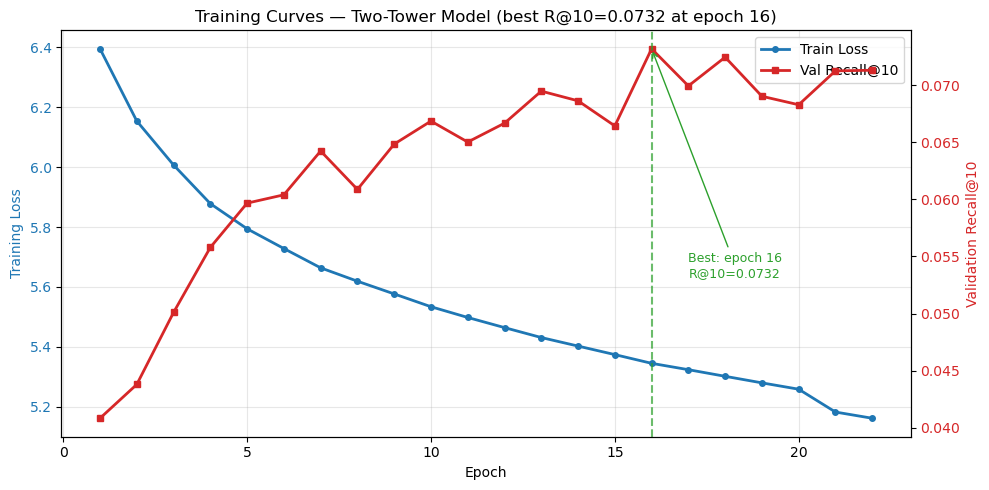

In [50]:
# ── Training curves ──
# Dual-axis plot: training loss (left) and validation Recall@10 (right)
# over epochs. The best-epoch marker (* in training output) is highlighted.

fig, ax1 = plt.subplots(figsize=(10, 5))

epochs = range(1, len(train_losses) + 1)

# Loss curve (left y-axis)
color_loss = "#1f77b4"
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Training Loss", color=color_loss)
ax1.plot(epochs, train_losses, color=color_loss, marker="o", linewidth=2, markersize=4, label="Train Loss")
ax1.tick_params(axis="y", labelcolor=color_loss)

# Recall curve (right y-axis)
ax2 = ax1.twinx()
color_recall = "#d62728"
ax2.set_ylabel("Validation Recall@10", color=color_recall)
ax2.plot(epochs, val_recalls, color=color_recall, marker="s", linewidth=2, markersize=4, label="Val Recall@10")
ax2.tick_params(axis="y", labelcolor=color_recall)

# Mark best epoch
best_idx = val_recalls.index(max(val_recalls))
best_epoch_plot = epochs[best_idx]
best_recall = val_recalls[best_idx]
ax2.axvline(x=best_epoch_plot, color="#2ca02c", linestyle="--", alpha=0.7, linewidth=1.5)
ax2.annotate(
    f"Best: epoch {best_epoch_plot}\nR@10={best_recall:.4f}",
    xy=(best_epoch_plot, best_recall),
    xytext=(best_epoch_plot + 1, best_recall - 0.02),
    arrowprops=dict(arrowstyle="->", color="#2ca02c"),
    fontsize=9,
    color="#2ca02c",
)

# Title and grid
ax1.set_title(f"Training Curves — Two-Tower Model (best R@10={best_recall:.4f} at epoch {best_epoch_plot})")
ax1.grid(True, alpha=0.3)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

fig.tight_layout()



In [52]:
# ── Ablation results summary ──
# Reads ablation_results.json (populated by each training run) and prints
# a cumulative comparison table. Run the notebook with ABLATION = "full",
# then "no_popularity", then "no_user_id", then "mean_pool" (cleaning
# processed/ and models/ before each run).

ablation_results_path = V1_DIR / "ablation_results.json"
if ablation_results_path.exists():
    all_results = json.loads(ablation_results_path.read_text())
    print("=" * 100)
    print(f"{'ABLATION RESULTS SUMMARY':^100}")
    print("=" * 100)
    print(f"{'Ablation':<16} {'Val HR@10':>10} {'Val R@10':>10} {'Test HR@10':>11} {'Test R@10':>11} {'Best Ep':>8} {'Time(min)':>10}")
    print("-" * 100)
    for r in sorted(all_results, key=lambda x: x.get("best_val_recall", 0), reverse=True):
        name = r.get("ablation", "?")
        vhr = r.get("val_model_hr10", float('nan'))
        vr = r.get("val_model_r10", float('nan'))
        thr = r.get("test_model_hr10", float('nan'))
        tr = r.get("test_model_r10", float('nan'))
        ep = r.get("best_epoch", "?")
        t = r.get("total_train_time_s", 0) / 60
        print(f"{name:<16} {vhr:>10.4f} {vr:>10.4f} {thr:>11.4f} {tr:>11.4f} {str(ep):>8} {t:>9.1f}")
    print("=" * 100)
    
    # Full metric breakdown
    print()
    print("=" * 100)
    print(f"{'FULL METRIC BREAKDOWN':^100}")
    print("=" * 100)
    print(f"{'Ablation':<16} {'Val HR':>8} {'Val P':>8} {'Val R':>8} {'Test HR':>9} {'Test P':>9} {'Test R':>9} {'Pop R':>8} {'Rand R':>8} {'Cont R':>8}")
    print("-" * 100)
    for r in sorted(all_results, key=lambda x: x.get("best_val_recall", 0), reverse=True):
        name = r.get("ablation", "?")
        print(f"{name:<16} "
              f"{r.get('val_model_hr10', float('nan')):>8.4f} "
              f"{r.get('val_model_p10', float('nan')):>8.4f} "
              f"{r.get('val_model_r10', float('nan')):>8.4f} "
              f"{r.get('test_model_hr10', float('nan')):>9.4f} "
              f"{r.get('test_model_p10', float('nan')):>9.4f} "
              f"{r.get('test_model_r10', float('nan')):>9.4f} "
              f"{r.get('val_pop_r10', float('nan')):>8.4f} "
              f"{r.get('val_random_r10', float('nan')):>8.4f} "
              f"{r.get('val_content_r10', float('nan')):>8.4f}")
    print("=" * 100)
else:
    print("No ablation_results.json found. Run the training cell (with ABLATION set) first.")




                                      ABLATION RESULTS SUMMARY                                      
Ablation          Val HR@10   Val R@10  Test HR@10   Test R@10  Best Ep  Time(min)
----------------------------------------------------------------------------------------------------
no_popularity        0.1737     0.0655      0.1433      0.0582        7       1.9
no_user_id           0.2176     0.0868      0.1973      0.0812       16       3.2
full                 0.1876     0.0721      0.1699      0.0678       18       3.4
mean_pool            0.1616     0.0572      0.1352      0.0549       22       3.3

                                       FULL METRIC BREAKDOWN                                        
Ablation           Val HR    Val P    Val R   Test HR    Test P    Test R    Pop R   Rand R   Cont R
----------------------------------------------------------------------------------------------------
no_popularity      0.1737   0.0193   0.0655    0.1433    0.0160    0.0582   0.0395 

In [53]:
# ── Cold-start recommendations ──
# Items that were filtered out during catalog stabilization (too few
# interactions) have no learned embeddings. They are ranked by a weighted
# blend of: positive interaction volume (60 %), positive ratio (25 %),
# and total review count (15 %) — all computed from the full training set.

def recommend_cold_start_v1(games_data, train_interactions, n=10):
    positive_popularity = (
        train_interactions[train_interactions["is_positive"] == 1]
        .groupby("app_id")
        .size()
        .rename("positive_interactions")
        .reset_index()
    )
    candidates = games_data.merge(
        positive_popularity,
        on="app_id",
        how="left",
    )
    candidates["positive_interactions"] = candidates[
        "positive_interactions"
    ].fillna(0)
    candidates["cold_start_score"] = (
        0.60 * candidates["positive_interactions"].rank(pct=True)
        + 0.25 * candidates["positive_ratio"].rank(pct=True)
        + 0.15 * candidates["user_reviews"].rank(pct=True)
    )
    candidates["warm_item_idx"] = candidates["app_id"].map(item_id_to_idx)

    return (
        candidates
        .sort_values("cold_start_score", ascending=False)
        [["app_id", "warm_item_idx", "cold_start_score"]]
        .head(n)
        .reset_index(drop=True)
    )

cold_start_recommendations = recommend_cold_start_v1(
    fallback_games,
    full_train_interactions,
    n=10,
)
cold_start_recommendations



,app_id,warm_item_idx,cold_start_score
0,620,22.0,0.980322
1,431960,1404.0,0.980239
2,400,16.0,0.979885
3,1145360,2325.0,0.979461
4,413150,1345.0,0.979136
5,294100,888.0,0.979136
6,253230,686.0,0.978290
7,546560,1649.0,0.977388
8,550,20.0,0.977097
9,460950,1481.0,0.976957
